# Lab 3: Generative & Discriminative Models

## Question 1: Sample from Generative Model

### 1.1 Load Unigram Model from Lab 1

In [1]:
import numpy as np 
import re

with open("AcademyAwardsWikipedia.txt", 'r') as f:
    corpus = f.read()

def tokenise(corpus):
    '''
    Converts string (corpus) to lowercase, removes punctuation and splits
    string on whitespace/new line characters. 

    args:
        corpus (str): Corpus (str): Corpus passed as a string..

    returns: 
        tokens (list): List of tokens (strings) 
    
    '''
    # Replace any thing not (^) alphanumeric (A-Za-z0-9) or a hyphen (-) with
    # an empty string. If you convert the text to lowercase first ^a-z0-9-\s 
    # would be sufficient. 
    corpus = re.sub(r'[^A-Za-z0-9-\s]','',corpus)
    corpus_lower = corpus.lower()
    # Split on whitespace/the new line character.
    tokens = corpus_lower.split()
    return tokens



class UnigramLanguageModel():
    '''
    Unigram model which can train on an existing corpus and evaluate on a 
    new query sentence. 
    
    '''
    def __init__(self):
        self.word_probs_dict = {}
        
    def train(self,corpus):
        '''
        Train language model on defined corpus by calculating word-level 
        probabilities. 
        
        args:
            corpus (str): Corpus passed to the method as a string.
        
        returns: 
            None
        '''
        # We want to count the frequency of each word so let's initalise a
        # dictionary. 
        word_freq_dict = {}
        # Tokenise string (corpus)
        tokens = tokenise(corpus)
        for token in tokens: 
            # Check if we already have the word in the frequency dictionary.
            # If we do, increase the count, otherwise count the word for the 
            # first time. 
            if token in word_freq_dict:
                word_freq_dict[token]+=1
            else:
                word_freq_dict[token] = 1
        # We need to count the total words in the corpus so we can calculate the probabilities. 
        total_words = sum([freq for freq in word_freq_dict.values()])   
        # The probability of each word is: (Count of word/number of words in corpus)
        # We'll use this later to calculate sentence probabilities
        self.word_probs_dict  = {token:freq/total_words for token, freq in word_freq_dict.items()}
        
    def test(self,sentence):
        '''
        Calculate the probability for a given sentence. 

        
        args:
            corpus (str): Sentence passed as a string.  
                          (Note: treats punctuation as the component of a word!)

        returns: 
            sentence_prob (float) Sentence probability for the given sentence. 
        '''
        
        word_probs = []
        # Tokenise string (sentence)
        tokens = tokenise(sentence)
        # Iterate through each word in string. 
        for token in tokens:
            if token in self.word_probs_dict:
                # Collect the probability for each word. 
                word_probs.append(self.word_probs_dict[token])
            else: 
                # If the word isn't in there, assign a probability of zero. 
                word_probs.append(0)
        # Multiply the probabilities by each other. 
        sentence_prob =  np.prod(word_probs)
        return sentence_prob
    
    
lm = UnigramLanguageModel()
lm.train(corpus)



### 1.2 Generate Sample from Unigram Model

In [2]:
import matplotlib.pyplot as plt
from collections import Counter
import random

plt.rcParams["figure.figsize"] = (20,10)

In [3]:
def sample_unigram_model(word_probs_dict, sample_size):
    '''
    Use a word probability dictionary to generate new data. 
    args:
        word_probs_dict (dict): Word dictionary with words as keys and counts as values. 
        sample_size (int): Size of sample to generate. 
        
    returns:
        sample (list): List containing words samples according to word count passed. 
    '''
    sample = []
    # Random value between 0 and 1
    while len(sample)<sample_size:
        for word, prob in word_probs_dict.items():
            rand_num = random.random()
            if prob >=rand_num:
                sample.append(word)
    return sample


### 1.3 Plot the following word counts of samples with the following sizes: 100, 1000, 10000 

In [6]:
sample_100 = sample_unigram_model(lm.word_probs_dict, 100)
sample_1000 = sample_unigram_model(lm.word_probs_dict, 1000)
sample_10000 = sample_unigram_model(lm.word_probs_dict, 10000)

In [7]:
def word_counts(tokens):
    '''
    Return list of words ordered by their frequency and a list of their counts. 
    args:
        tokens (list): List of tokens in a document. 

    returns:
        words (list): List of words ordered by their frequency in the "tokens" list.
        counts (list): List of counts for "words" list. 
    
    '''
    # count each word in the sample
    count_dict = Counter(tokens)
    # Sort counts for visualisation
    words = []
    counts=[]
    for word, count in sorted(count_dict.items(), key=lambda x: x[1]):
        words.append(word)
        counts.append(count)
    return words, counts

def plot_word_counts(tokens):
    '''
    Plot the word counts from a list of tokens. 
    args:
        tokens (list): List of tokens

    returns:
        None
    '''
    sample_words, sample_counts = word_counts(tokens)
    plt.bar(range(len(sample_counts)), list(sample_counts), align='center')
    plt.xticks(range(len(sample_words)), list(sample_words), rotation=90)
    plt.show()



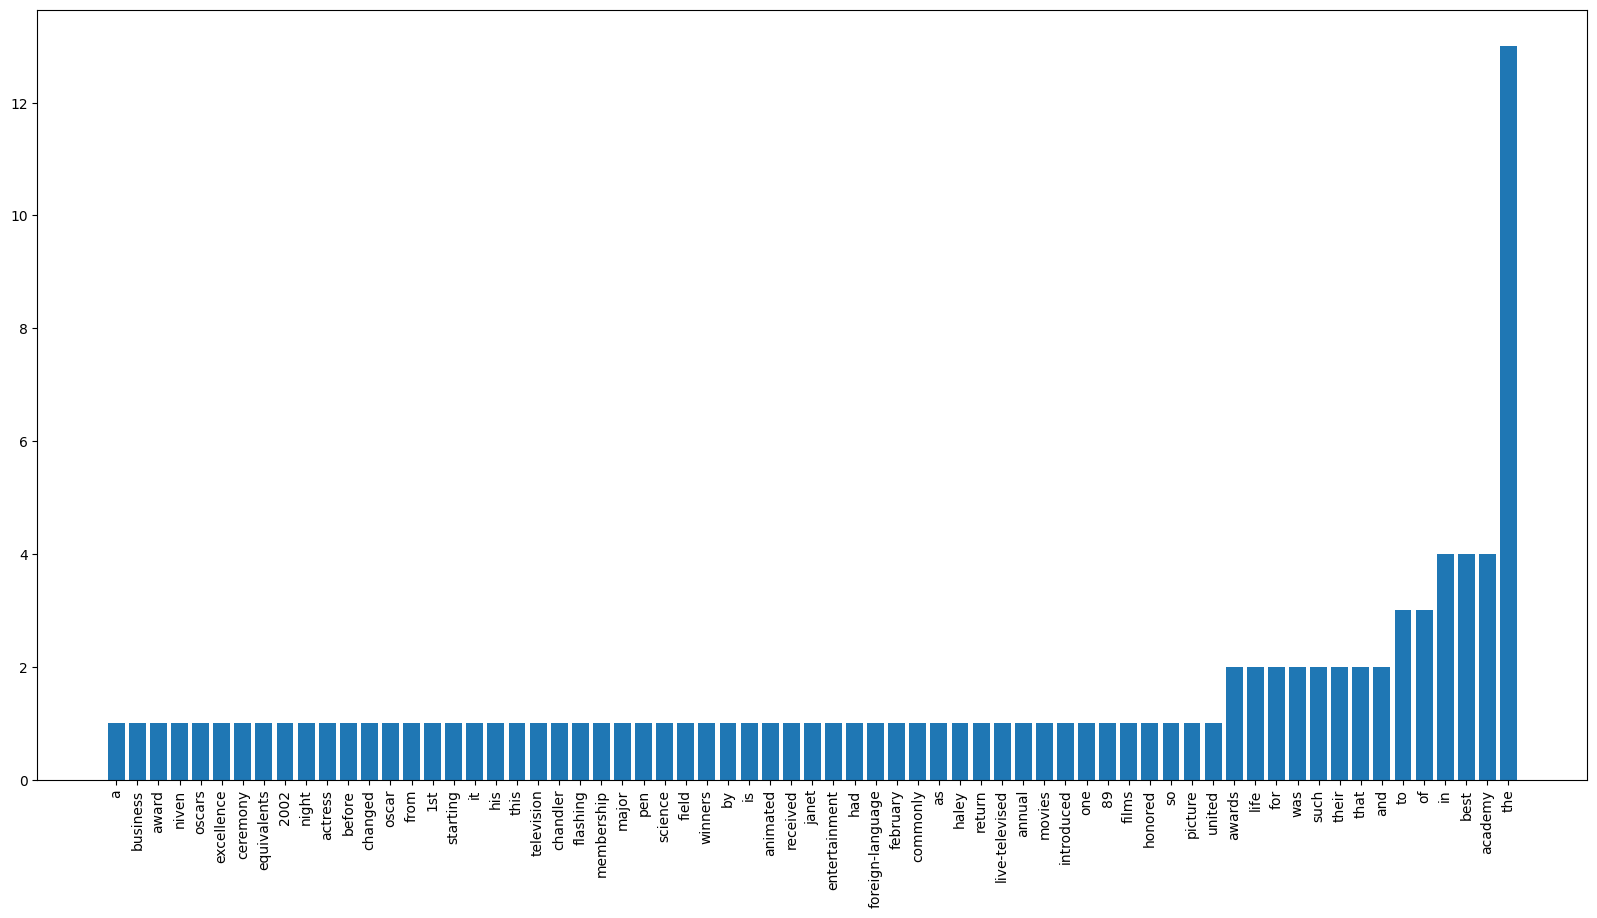

In [8]:
plot_word_counts(sample_100)

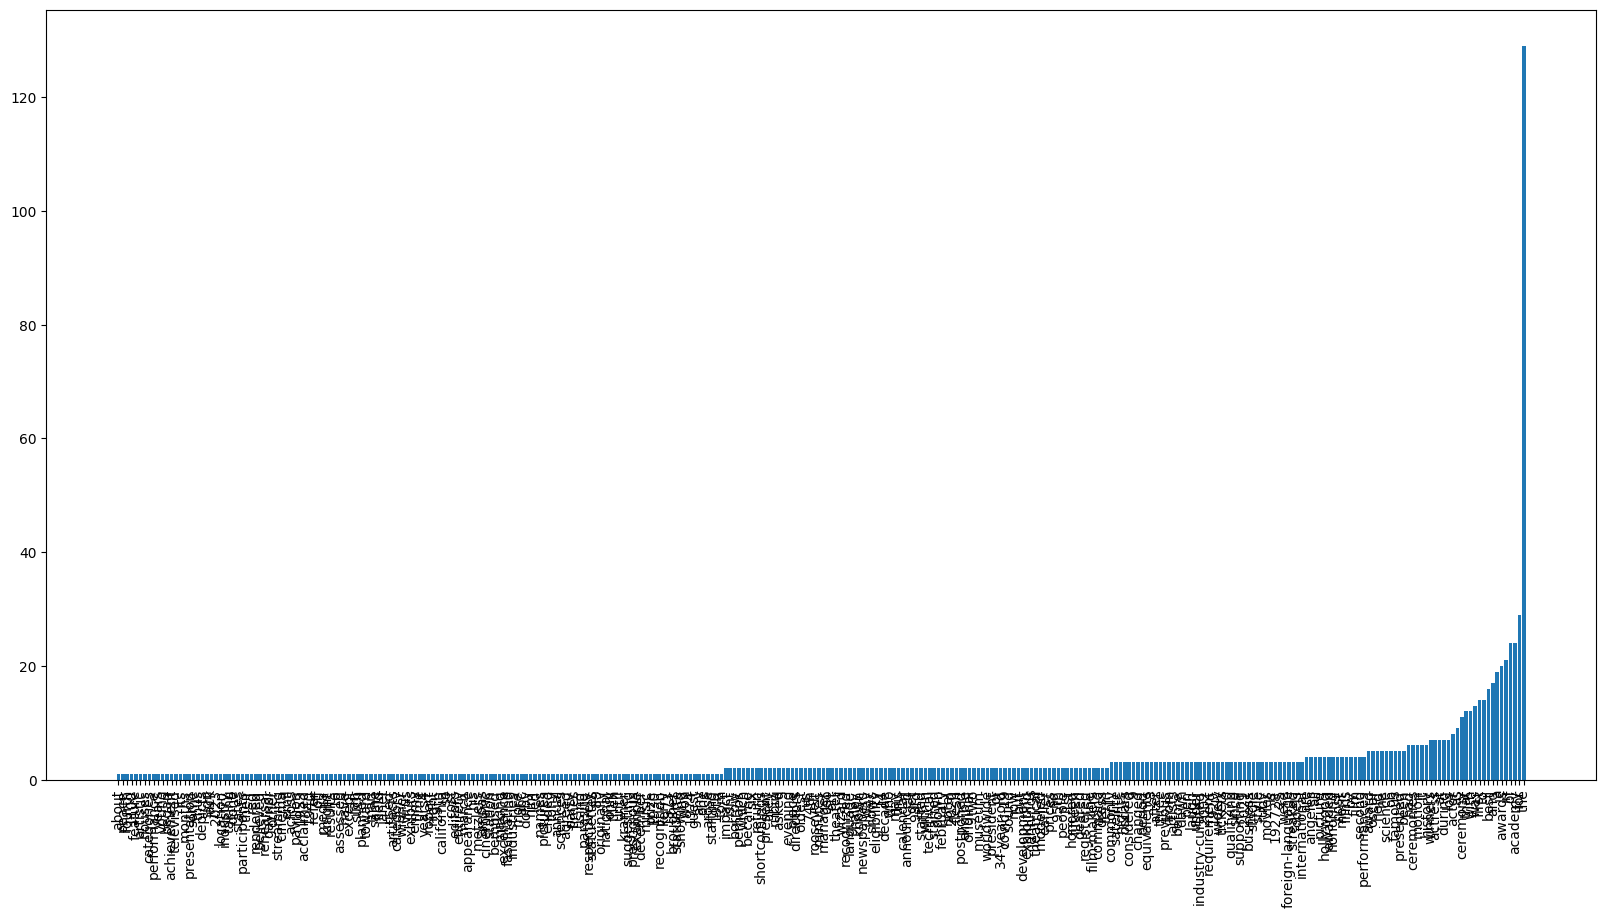

In [9]:
plot_word_counts(sample_1000)

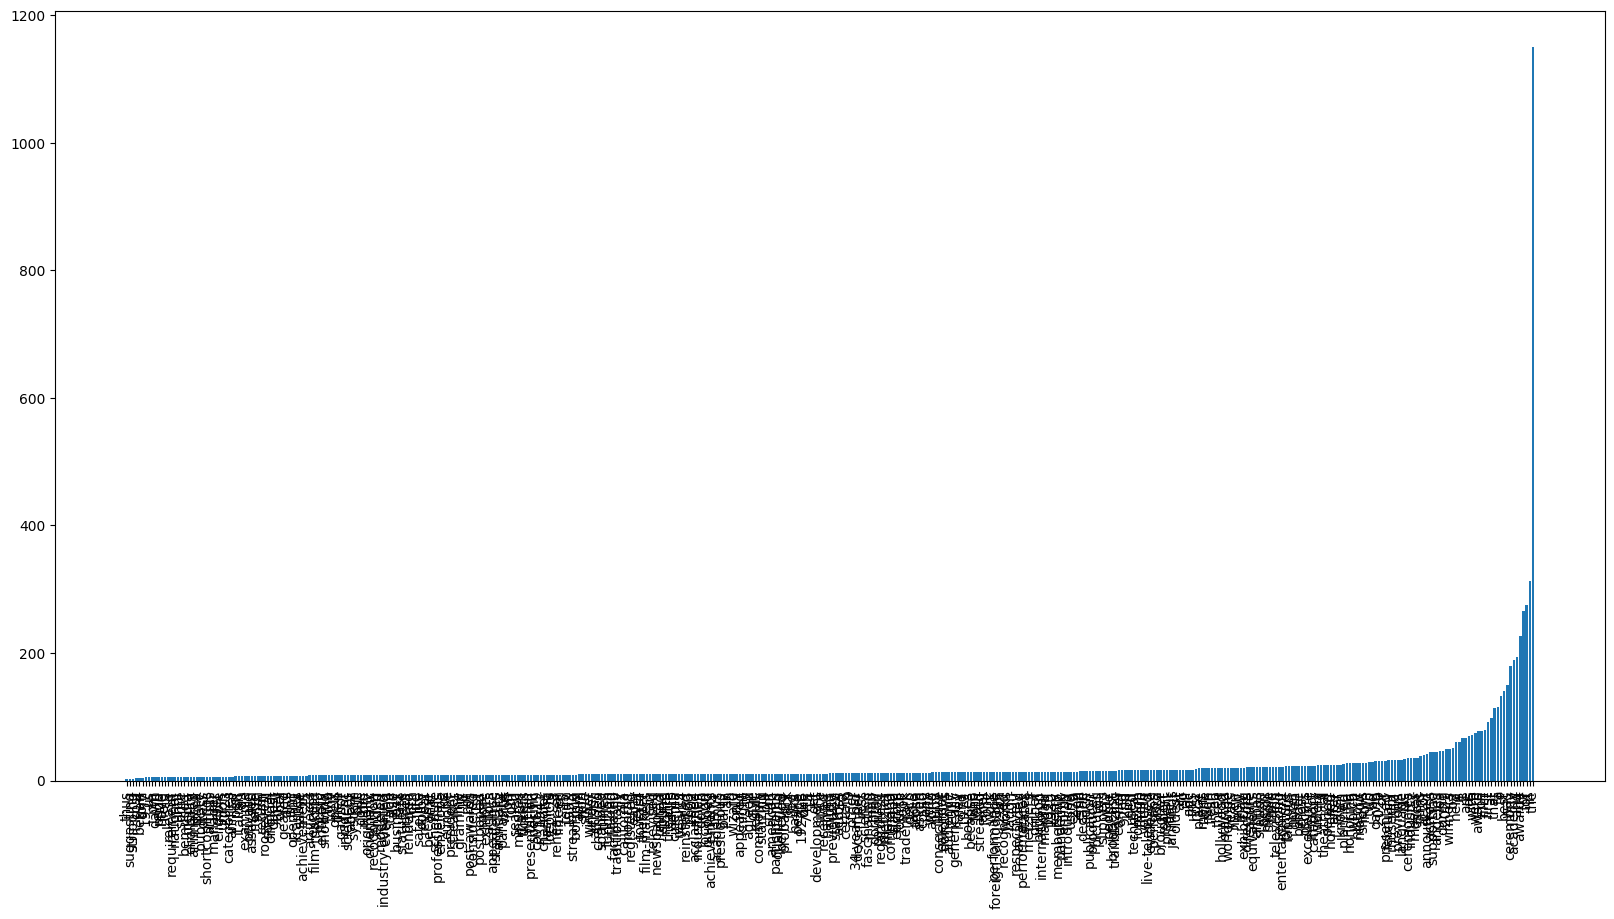

In [10]:
plot_word_counts(sample_10000)

### 1.4 Plot the word counts of the original corpus

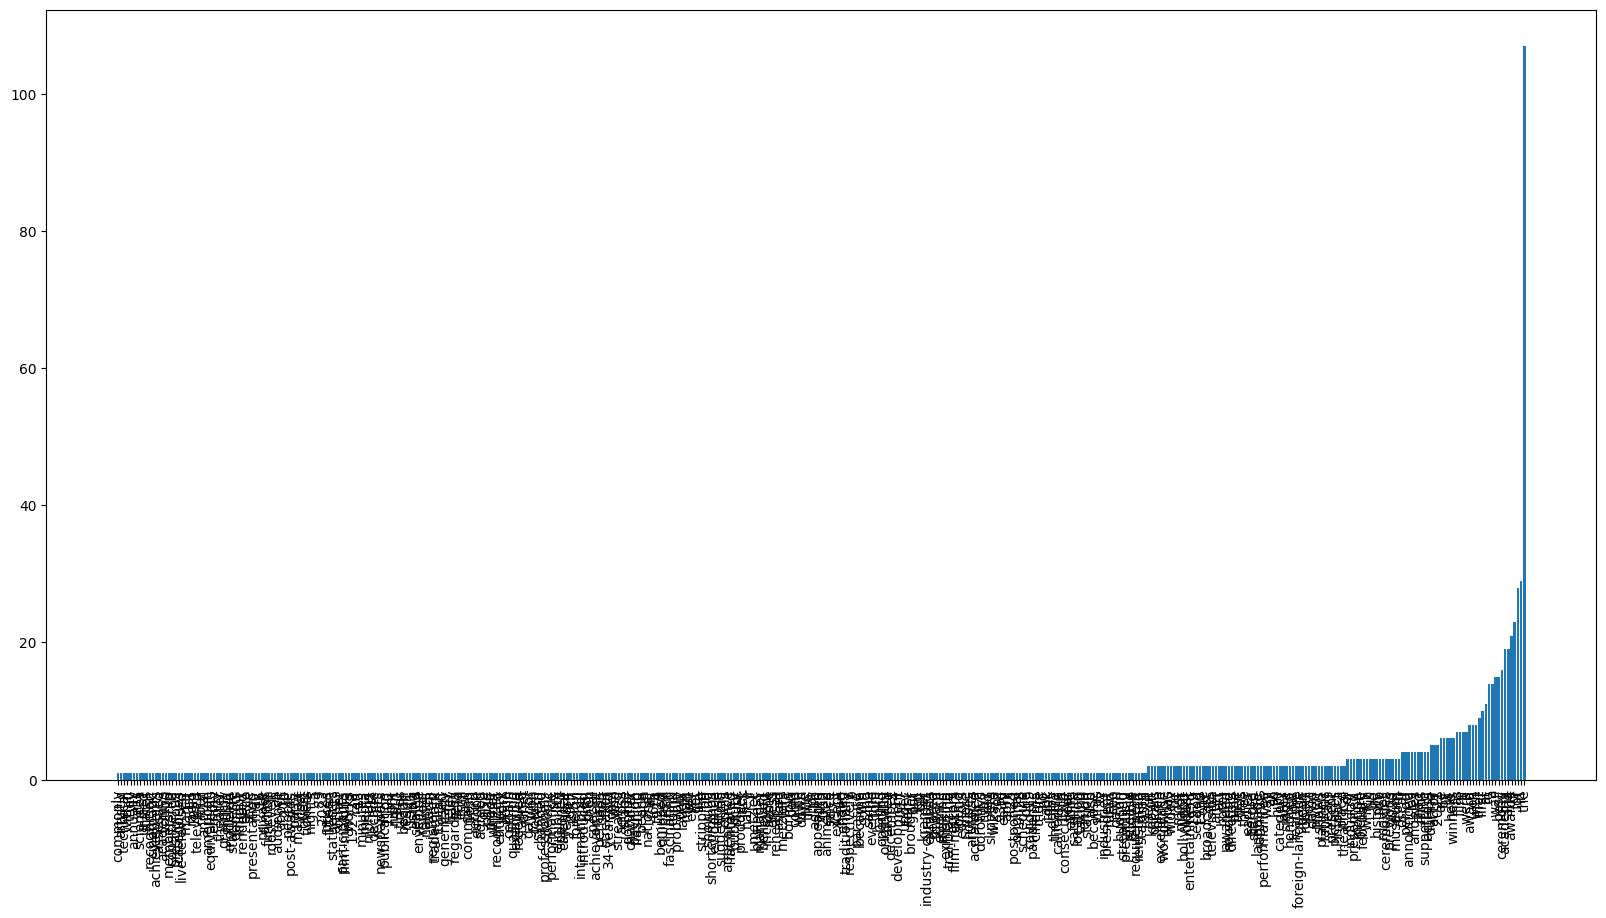

In [18]:
tokens = tokenise(corpus)
plot_word_counts(tokens)

## Question 2: Logistic Regression
Use the scikit-learn implementation of Logistic Regression to train a model on the Nigerian English topic classification dataset that was used in Lab 2. 

In [19]:
# To install dependencies, uncomment the code below
# ! pip install huggingface_hub pandas numpy scikit-learn

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd
splits = {'train': 'train.csv', 'test': 'test.csv'}
train_df = pd.read_csv("hf://datasets/okite97/news-data/" + splits["train"])
test_df = pd.read_csv("hf://datasets/okite97/news-data/" + splits["test"])

In [12]:
vectorizer = CountVectorizer()

count_vectoriser = vectorizer.fit(train_df["Excerpt"].values) 
train_X = vectorizer.transform(train_df["Excerpt"].values) 
test_X = vectorizer.transform(test_df["Excerpt"].values) 

model = LogisticRegression().fit(train_X.toarray(),train_df.Category)

train_preds = model.predict(train_X.toarray())
test_preds = model.predict(test_X.toarray())

print(classification_report(train_df.Category, train_preds))
print(classification_report(test_df.Category, test_preds))


               precision    recall  f1-score   support

     business       0.95      0.96      0.96      1268
entertainment       0.98      0.97      0.98       382
       health       0.99      0.97      0.98       550
     politics       0.99      0.99      0.99      1073
       sports       0.99      1.00      1.00      1124
         tech       0.83      0.79      0.81       289

     accuracy                           0.97      4686
    macro avg       0.96      0.95      0.95      4686
 weighted avg       0.97      0.97      0.97      4686

               precision    recall  f1-score   support

     business       0.73      0.85      0.79       224
entertainment       0.87      0.72      0.79        67
       health       0.89      0.74      0.81        97
     politics       0.88      0.89      0.89       190
       sports       0.92      0.95      0.93       199
         tech       0.45      0.29      0.36        51

     accuracy                           0.83       828
    m